In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
prices = pd.read_csv("prices_round_1_day_-1.csv", sep=";")
trades = pd.read_csv("trades_round_1_day_-1.csv", sep=";")

print(prices.head())
print(prices.columns.tolist())
print(trades.head())

   day  timestamp               product  bid_price_1  bid_volume_1  \
0   -1          0  INTARIAN_PEPPER_ROOT      10991.0          15.0   
1   -1          0     ASH_COATED_OSMIUM          NaN           NaN   
2   -1        100     ASH_COATED_OSMIUM       9984.0          11.0   
3   -1        100  INTARIAN_PEPPER_ROOT      10994.0           9.0   
4   -1        200     ASH_COATED_OSMIUM       9985.0          15.0   

   bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
0          NaN           NaN          NaN           NaN      11006.0   
1          NaN           NaN          NaN           NaN      10003.0   
2          NaN           NaN          NaN           NaN      10000.0   
3      10991.0          21.0          NaN           NaN      11006.0   
4       9982.0          20.0          NaN           NaN      10001.0   

   ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  \
0          10.0      11009.0          15.0          NaN           NaN   


In [4]:
print(prices["product"].unique())
print(f"Shape: {prices.shape}")

['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
Shape: (20000, 17)


In [5]:
# ── 2. SPLIT BY PRODUCT ───────────────────────────────────────────────────────
pepper = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy().reset_index(drop=True)
osmium = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy().reset_index(drop=True)

print(f"Pepper rows: {len(pepper)}, Osmium rows: {len(osmium)}")

Pepper rows: 10000, Osmium rows: 10000


In [6]:
# ── 3. COMPUTE MID + MICRO PRICE ─────────────────────────────────────────────
def add_prices(df):
    df["mid_price"] = (df["bid_price_1"] + df["ask_price_1"]) / 2
    # Micro price: volume-weighted mid (handles NaN gracefully)
    df["micro_price"] = (
        df["bid_price_1"] * df["ask_volume_1"] + df["ask_price_1"] * df["bid_volume_1"]
    ) / (df["bid_volume_1"] + df["ask_volume_1"])
    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    return df

pepper = add_prices(pepper)
osmium = add_prices(osmium)

print(pepper[["day", "timestamp", "mid_price", "micro_price", "spread"]].head(10))

   day  timestamp  mid_price   micro_price  spread
0   -1          0    10998.5  11000.000000    15.0
1   -1        100    11000.0  11000.000000    12.0
2   -1        200    11001.5  10999.000000    15.0
3   -1        300        NaN           NaN     NaN
4   -1        400    10999.0  11001.032258    14.0
5   -1        500    11000.0  11000.000000    12.0
6   -1        600    11002.0  10998.705882    14.0
7   -1        700    11001.0  11001.000000    12.0
8   -1        800    10999.5  11001.375000    15.0
9   -1        900    11001.0  11001.000000    12.0


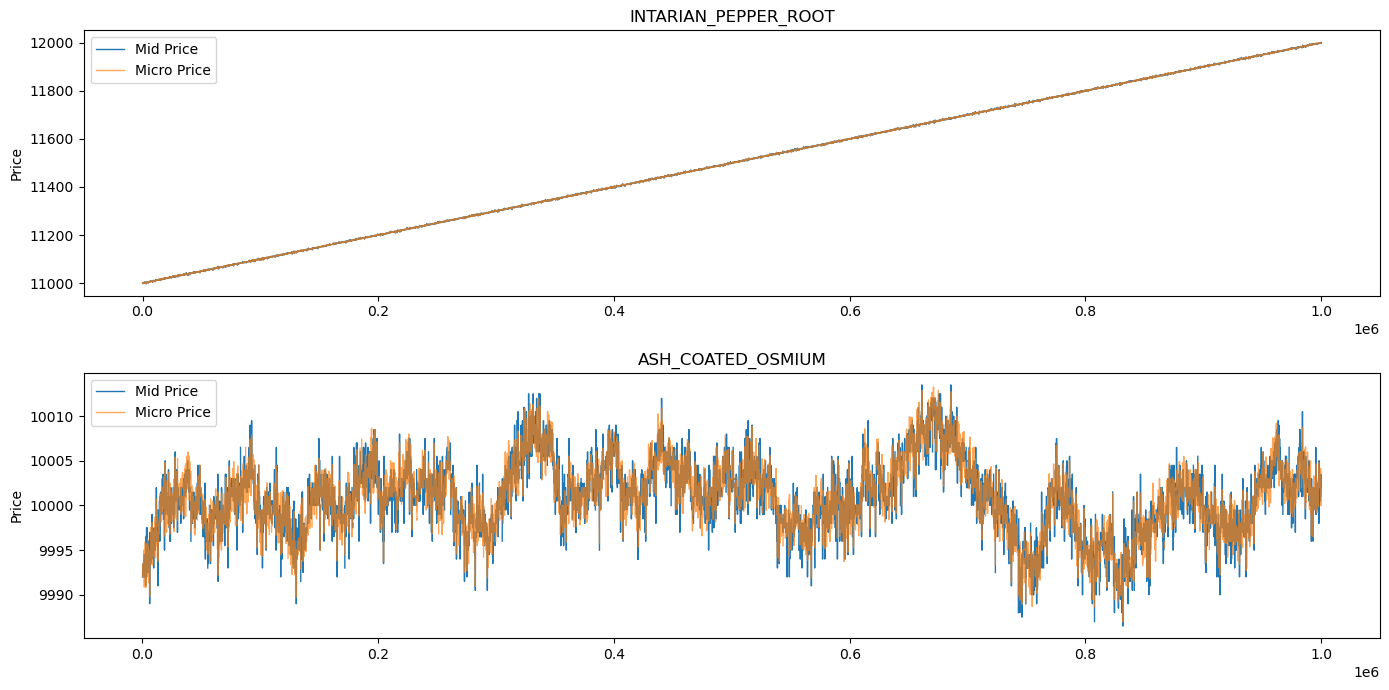

In [14]:
# ── 4. PLOT BOTH PRODUCTS SIDE BY SIDE ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, df, name in zip(axes, [pepper, osmium], ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]):
    ax.plot(df["timestamp"], df["mid_price"], label="Mid Price", linewidth=1)
    ax.plot(df["timestamp"], df["micro_price"], label="Micro Price", linewidth=1, alpha=0.7)
    ax.set_title(name)
    ax.set_ylabel("Price")
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# ── PEPPER: check if it's truly linear ───────────────────────────────────────
import numpy as np

x = np.arange(len(pepper))
coeffs = np.polyfit(x, pepper["mid_price"].fillna(method="ffill"), 1)
print(f"Pepper slope: {coeffs[0]:.4f} per timestamp")
print(f"Pepper intercept: {coeffs[1]:.2f}")
# A clean slope with low residuals = trend follow it

Pepper slope: 0.1000 per timestamp
Pepper intercept: 10999.94


/var/folders/gr/kpqp8bx52dd4_c8ptgybzcx80000gn/T/ipykernel_79636/3222455311.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  coeffs = np.polyfit(x, pepper["mid_price"].fillna(method="ffill"), 1)


In [17]:
# ── OSMIUM: confirm fair value is 10,000 ─────────────────────────────────────
print(f"Osmium mean:   {osmium['mid_price'].mean():.2f}")
print(f"Osmium std:    {osmium['mid_price'].std():.2f}")
print(f"Osmium median: {osmium['mid_price'].median():.2f}")
# If mean ≈ median ≈ 10000, market-make around 10000

Osmium mean:   10000.83
Osmium std:    3.83
Osmium median: 10001.00


count    9225.000000
mean        0.833550
std         3.825387
min       -13.500000
25%        -2.000000
50%         1.000000
75%         3.000000
max        13.500000
Name: mid_price, dtype: float64


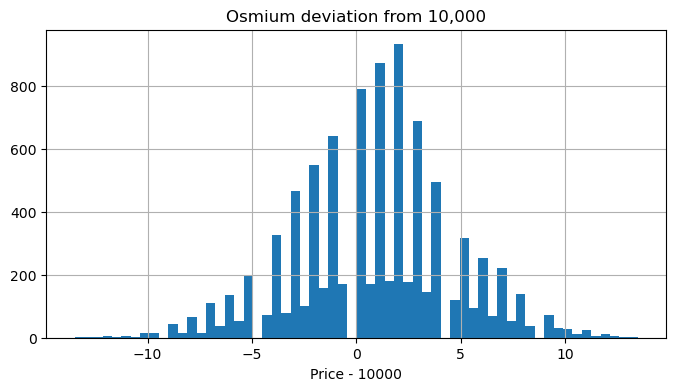

In [18]:
# ── OSMIUM: find the optimal market-making offset ────────────────────────────
# How far does price typically deviate? That tells you where to place orders
deviations = osmium["mid_price"] - 10000
print(deviations.describe())

import matplotlib.pyplot as plt
deviations.hist(bins=60, figsize=(8, 4))
plt.title("Osmium deviation from 10,000")
plt.xlabel("Price - 10000")
plt.show()
# Place buy orders at 10000 - offset, sell at 10000 + offset

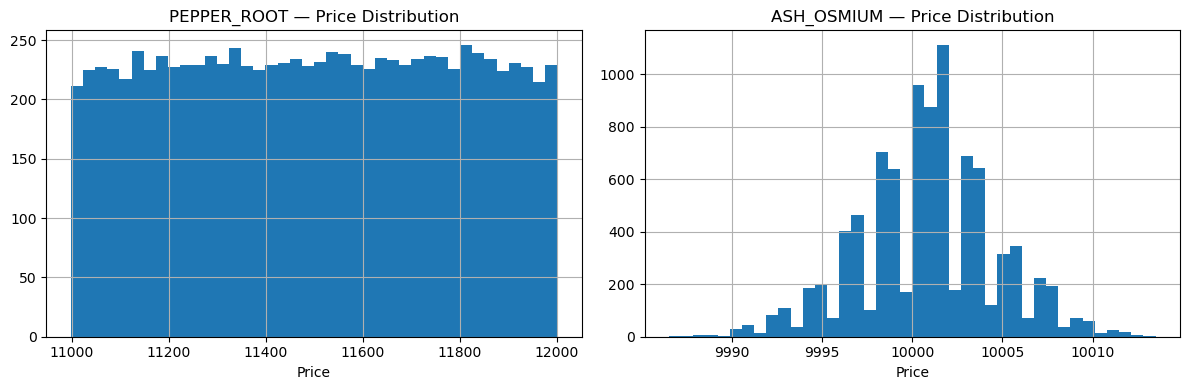

In [8]:
# ── 5. PRICE DISTRIBUTION — stable or drifting? ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, name in zip(axes, [pepper, osmium], ["PEPPER_ROOT", "ASH_OSMIUM"]):
    df["mid_price"].hist(bins=40, ax=ax)
    ax.set_title(f"{name} — Price Distribution")
    ax.set_xlabel("Price")

plt.tight_layout()
plt.show()

# Tight cluster around one value → market-make it
# Wide / spread out → use EMA or trend following

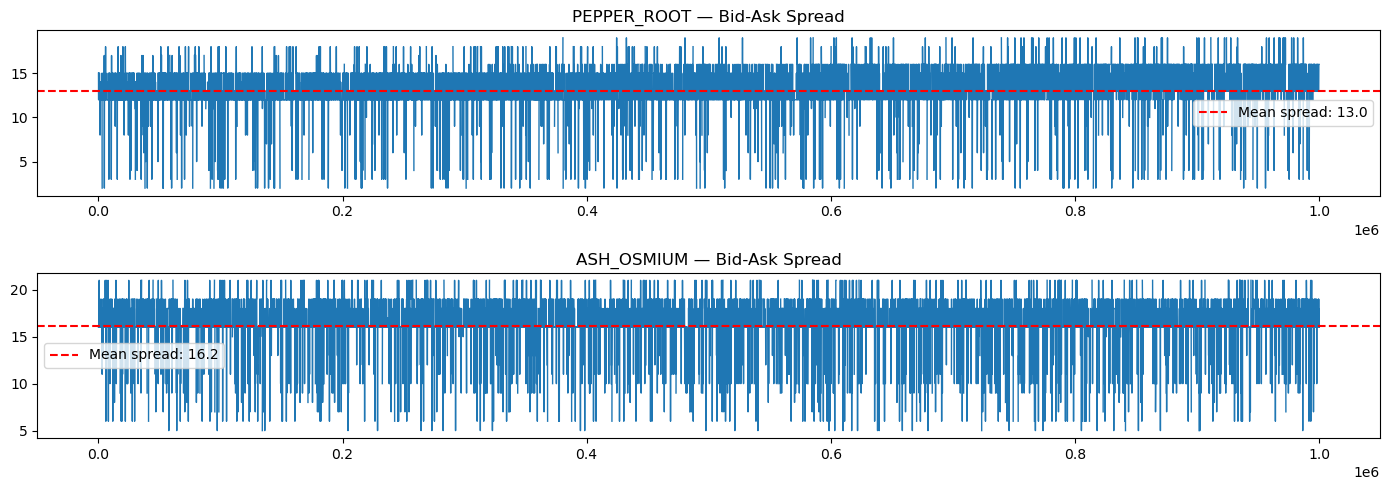

In [9]:
# ── 6. SPREAD ANALYSIS ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

for ax, df, name in zip(axes, [pepper, osmium], ["PEPPER_ROOT", "ASH_OSMIUM"]):
    ax.plot(df["timestamp"], df["spread"], linewidth=1)
    ax.axhline(df["spread"].mean(), color="red", linestyle="--", label=f"Mean spread: {df['spread'].mean():.1f}")
    ax.set_title(f"{name} — Bid-Ask Spread")
    ax.legend()

plt.tight_layout()
plt.show()

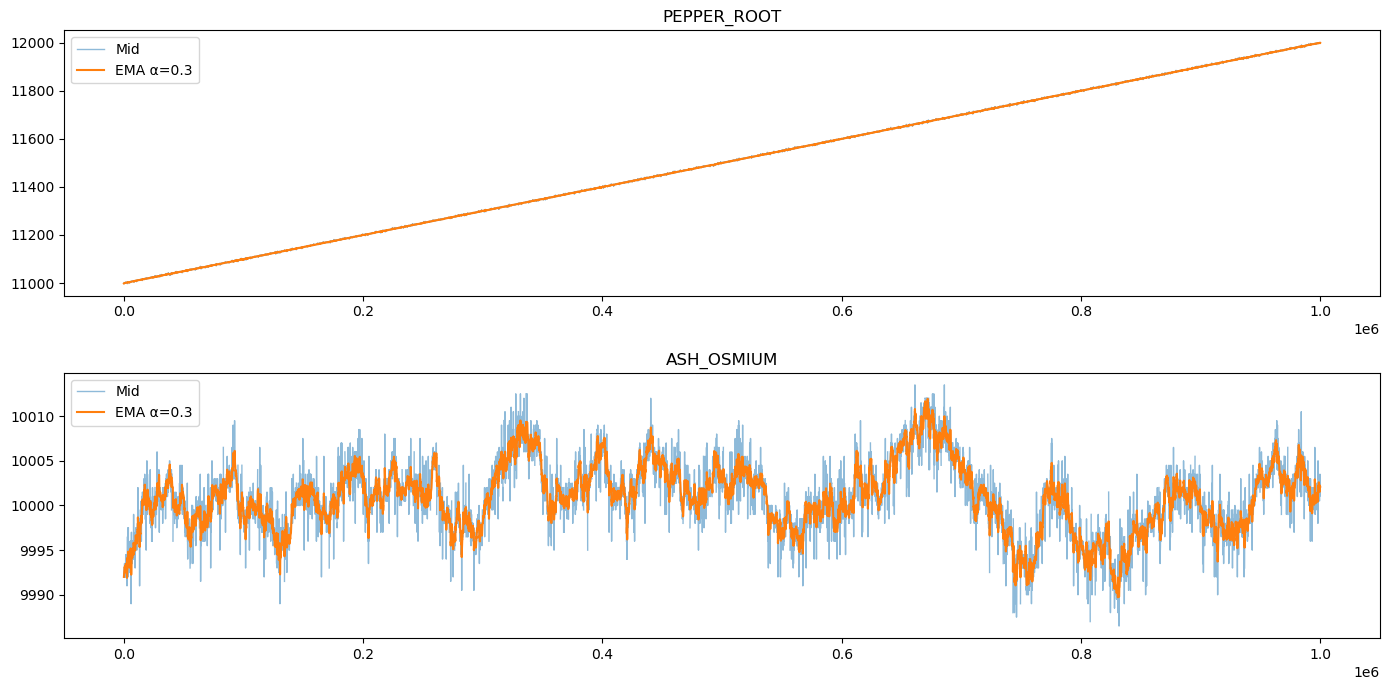

In [10]:
# ── 7. EMA — useful if price is trending ─────────────────────────────────────
alpha = 0.3

for df, name in zip([pepper, osmium], ["PEPPER_ROOT", "ASH_OSMIUM"]):
    df["ema"] = df["mid_price"].ewm(alpha=alpha, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, df, name in zip(axes, [pepper, osmium], ["PEPPER_ROOT", "ASH_OSMIUM"]):
    ax.plot(df["timestamp"], df["mid_price"], label="Mid", linewidth=1, alpha=0.5)
    ax.plot(df["timestamp"], df["ema"], label=f"EMA α={alpha}", linewidth=1.5)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

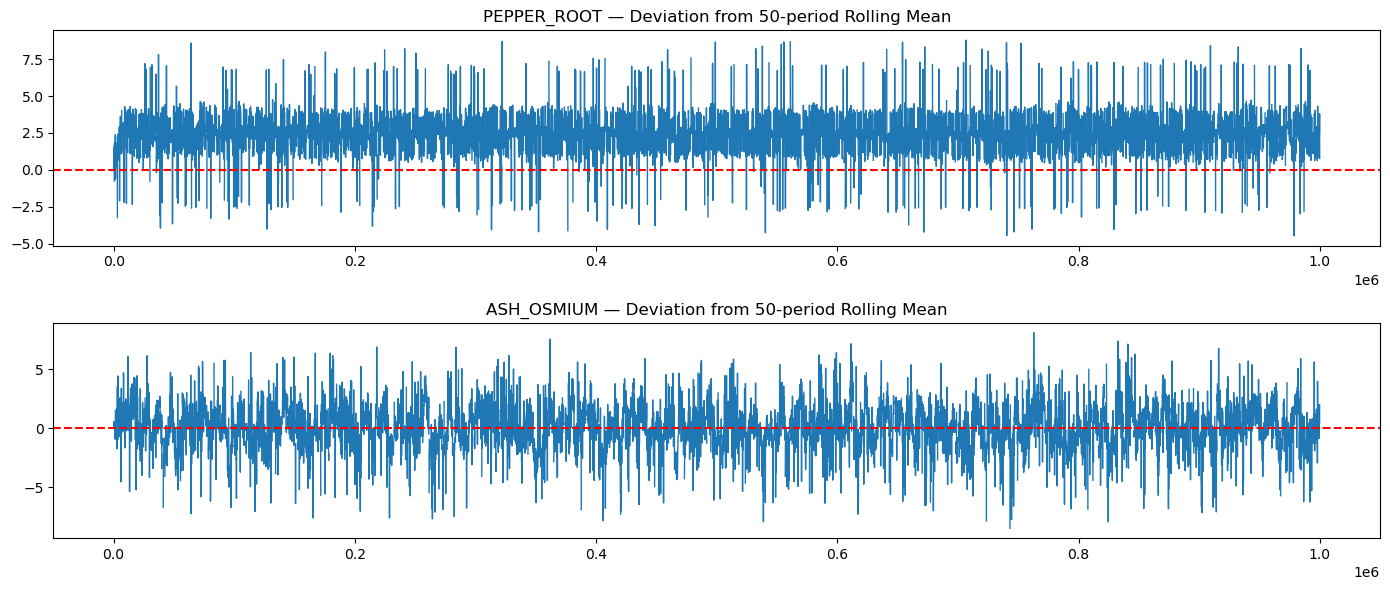

In [11]:
# ── 8. MEAN REVERSION CHECK ───────────────────────────────────────────────────
# How much does price deviate from its rolling mean?
window = 50

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for ax, df, name in zip(axes, [pepper, osmium], ["PEPPER_ROOT", "ASH_OSMIUM"]):
    rolling_mean = df["mid_price"].rolling(window, min_periods=1).mean()
    deviation = df["mid_price"] - rolling_mean
    ax.plot(df["timestamp"], deviation, linewidth=1)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"{name} — Deviation from {window}-period Rolling Mean")

plt.tight_layout()
plt.show()

Correlation between products: -0.0650


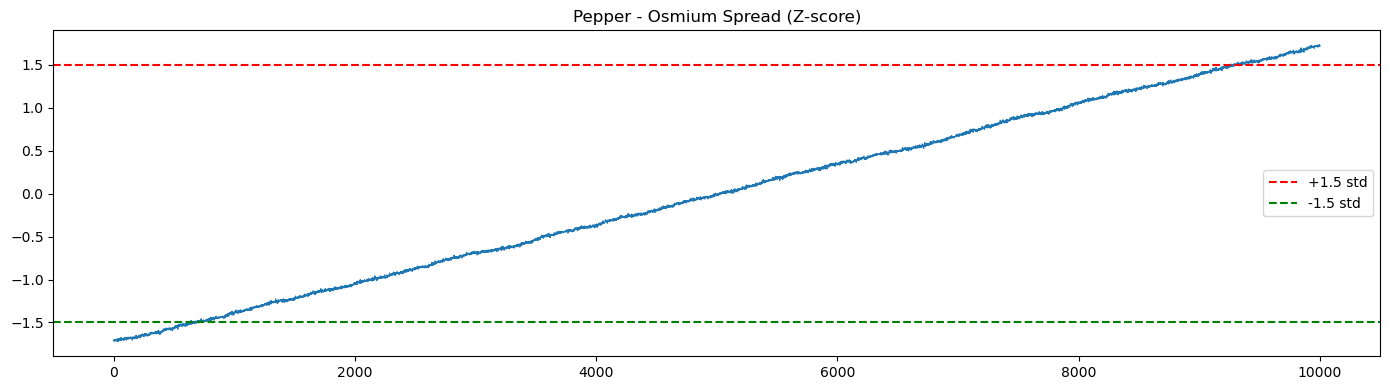

In [12]:
# ── 9. ARE THEY CORRELATED? (pairs trading opportunity) ──────────────────────
# Merge on timestamp + day to align them
merged = pd.merge(
    pepper[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "pepper"}),
    osmium[["day", "timestamp", "mid_price"]].rename(columns={"mid_price": "osmium"}),
    on=["day", "timestamp"],
    how="inner"
)

corr = merged["pepper"].corr(merged["osmium"])
print(f"Correlation between products: {corr:.4f}")

# If abs(corr) > 0.8, consider a spread/pairs strategy
spread = merged["pepper"] - merged["osmium"]
spread_z = (spread - spread.mean()) / spread.std()

plt.figure(figsize=(14, 4))
plt.plot(spread_z.values, linewidth=1)
plt.axhline(1.5, color="red", linestyle="--", label="+1.5 std")
plt.axhline(-1.5, color="green", linestyle="--", label="-1.5 std")
plt.title("Pepper - Osmium Spread (Z-score)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 10. SUMMARY STATS ─────────────────────────────────────────────────────────
for df, name in zip([pepper, osmium], ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]):
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"  Mid price mean:   {df['mid_price'].mean():.2f}")
    print(f"  Mid price std:    {df['mid_price'].std():.2f}")
    print(f"  Avg spread:       {df['spread'].mean():.2f}")
    print(f"  NaN rows (bid1):  {df['bid_price_1'].isna().sum()}")


INTARIAN_PEPPER_ROOT
  Mid price mean:   11501.41
  Mid price std:    287.64
  Avg spread:       13.01
  NaN rows (bid1):  415

ASH_COATED_OSMIUM
  Mid price mean:   10000.83
  Mid price std:    3.83
  Avg spread:       16.19
  NaN rows (bid1):  398
